In [29]:
import math
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import os
import math

**Loading files**

In [30]:
folder_path = '/content/EE 770/'
files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]
print(files)

['Erode_Tamilnadu.xlsx', 'IITB.xlsx', 'Muzaffarpur_Bihar.xlsx', 'Miryalaguda_Telangana.xlsx', 'Srikukalan_Andhra.xlsx']


In [31]:
#Given values for solar geometry
def location(weather_data):
    if weather_data == 'Erode_Tamilnadu.xlsx':
        Longitude = 77.57    #values in degrees
        Latitude = 11.56
    elif weather_data == 'Muzaffarpur_Bihar.xlsx':
        Longitude = 85.39    #values in degrees
        Latitude = 26.12
    elif weather_data == 'Srikukalan_Andhra.xlsx':
        Longitude = 83.91    #values in degrees
        Latitude = 18.28
    elif weather_data == 'IITB.xlsx':
        Longitude = 72.9    #values in degrees
        Latitude = 19.13
    elif weather_data == 'Miryalaguda_Telangana.xlsx':
        Longitude= 79.57
        Latitude = 16.88
    return [Latitude,Longitude]

In [32]:
def timeslot_calculation(weather_data):
    weather_data = pd.read_excel('/content/EE 770/' + weather_data) #Loading weather file
    df = pd.DataFrame(weather_data)  # Changing the excel into dataframe
    # Converting cummulative hour to respective days and creating a new column
    df = df.drop('Hour', axis =1)
    df.index = range(1, 8761)
    Days= []
    for i in df.index:
        day = math.ceil(i/24)
        Days.append(day)
    df['Days'] = Days
    #Calculating delta for all the days
    delta= []
    for i in df['Days']:
        theta_degree = 360 * (284 + i) / 365
        theta_radian = math.radians(theta_degree)
        de = 23.45 * math.sin(theta_radian)
        delta.append(de)
    df['Delta'] = delta   #Creating new column for delta
    #For hour angle calculation, individual hours of a day is needed
    hours = np.tile(np.arange(1,25), 365)
    df['time_slot'] = hours
    return df

In [33]:
#Calculating hour angle
def calculating_hourangle(df, Longitude):
    Hour_angle = []
    for i,j in zip(df['Days'], df['time_slot']):
        B_degree = (i -1) * 360 / 365
        B = math.radians(B_degree)
        E = 229.18 * (0.000075 + 0.001868 * math.cos(B) - 0.032077*math.sin(B) - 0.014615* math.cos(2*B) - 0.04089* math.sin(2*B))
        mins = 4 * (Longitude - 82.5) + E
        LAT = j + (mins/60) - 0.5 #Data is for average at 30 mins in between hours, so minus 0.5 hours
        hour_angle = (LAT-12) * 15
        Hour_angle.append(hour_angle)
    df['Hour_angle'] = Hour_angle # Creating new column for hour angle
    return df

In [34]:
def optimization(df,Latitude,file_name, Cordinates):
    pi = math.radians(Latitude)
    # Objective function to maximize (negative because we'll minimize it)
    def func(params):
        beta,gamma = params
        beta = math.radians(beta)    #beta and gamma are variables
        gamma = math.radians(gamma)

        Cos_theta_values = []
        Cos_theta_z = []
        for i, j in zip(df['Delta'], df['Hour_angle']):
            delta = math.radians(i)
            omega = math.radians(j)
            A = (math.cos(delta) * math.cos(omega) * math.sin(pi)) - (math.sin(delta)* math.cos(pi))
            B = math.sin(beta) * math.sin(gamma) * math.cos(delta) * math.sin(omega)
            C = (math.cos(delta) * math.cos(omega) * math.cos(pi)) + (math.sin(delta) * math.sin(pi))
            CTheta = (math.sin(beta) * math.cos(gamma) * A) + B + (math.cos(beta) * C)
            Cos_theta_values.append(CTheta)
            CTheta_Z = C
            Cos_theta_z.append(CTheta_Z)
        df['Cos_theta'] = Cos_theta_values
        df['Cos_theta_z'] = Cos_theta_values
        k = df['DNI'].to_numpy()              #Converting the dni values into numpy for array multiplication
        Costheta = df['Cos_theta'].to_numpy()
        i = df['Cos_theta'].to_numpy()   #Cos_theta
        j = df['Cos_theta_z'].to_numpy()  #Cos_theta_z
        l= df['DHI'].to_numpy()           #Id
        cos_beta = math.cos(math.radians(beta))
        rd = (1 + cos_beta) / 2                 #Diffuse_reflectivity
        rr = 0.2 * (1 - cos_beta) / 2  #Radiation_reflectivity
        It_liu = (k * i) + (l * rd) + ((k + l) * rr) #Intensity_tilted
        It_liu = It_liu.tolist()
        df['EPOA'] = It_liu
        total = np.sum(df['EPOA'])
        return -total
    # Initial guess for beta and gamma (in degrees)
    initial_guess = [20,15]

    # Bounds for beta and gamma (in degrees)
    bounds = [(0, 90), (-180,180)]

    # Optimization
    result = minimize(func, initial_guess, bounds=bounds, method='L-BFGS-B')
    optimal_beta, optimal_gamma = result.x
    Max_I_Costheta = -result.fun
    filename = file_name.strip('.xlsx')
    print(f'For Bifacial {filename} {Cordinates}:')
    print(f'Optimal beta: {optimal_beta:.2f}°')
    print(f'Optimal gamma: {optimal_gamma:.2f}°')
    print(f'Maximum  EPOA: {round(Max_I_Costheta)} W/m^2')
    print()

In [35]:
def Standard(df,Latitude,file_name, Cordinates, gamma_value):
    pi = math.radians(Latitude)
    beta = pi
    gamma = gamma_value
    Cos_theta_values = []
    Cos_theta_z = []
    for i, j in zip(df['Delta'], df['Hour_angle']):
        delta = math.radians(i)
        omega = math.radians(j)
        A = (math.cos(delta) * math.cos(omega) * math.sin(pi)) - (math.sin(delta)* math.cos(pi))
        B = math.sin(beta) * math.sin(gamma) * math.cos(delta) * math.sin(omega)
        C = (math.cos(delta) * math.cos(omega) * math.cos(pi)) + (math.sin(delta) * math.sin(pi))
        CTheta = (math.sin(beta) * math.cos(gamma) * A) + B + (math.cos(beta) * C)
        Cos_theta_values.append(CTheta)
        CTheta_Z = C
        Cos_theta_z.append(CTheta_Z)
    df['Cos_theta'] = Cos_theta_values
    df['Cos_theta_z'] = Cos_theta_values
    k = df['DNI'].to_numpy()              #Converting the dni values into numpy for array multiplication
    Costheta = df['Cos_theta'].to_numpy()
    i = df['Cos_theta'].to_numpy()   #Cos_theta
    j = df['Cos_theta_z'].to_numpy()  #Cos_theta_z
    l= df['DHI'].to_numpy()           #Id
    cos_beta = math.cos(math.radians(beta))
    rd = (1 + cos_beta) / 2                 #Diffuse_reflectivity
    rr = 0.2 * (1 - cos_beta) / 2  #Radiation_reflectivity
    It_liu = (k * i) + (l * rd) + ((k + l) * rr) #Intensity_tilted
    It_liu = It_liu.tolist()
    df['EPOA'] = It_liu
    total = np.sum(df['EPOA'])
    filename = file_name.strip('.xlsx')
    print(f'For Bifacial {filename} {Cordinates}:')
    print(f'Standard Beta: {Cordinates[0]}°')
    print(f'Standard Gamma: {gamma}°')
    print(f'Maximum  EPOA: {round(total)} W/m^2')
    print()
    return round(total)

**Calulating annual irradiance for different orientation**

In [36]:
Cordinates = location(files[1])
a = timeslot_calculation(files[1])
b = calculating_hourangle(a, Cordinates[1])
y = []
x = []
for i in range(-180,180,45):
    t = Standard(b, Cordinates[0],files[1], Cordinates,i)
    y.append(t/1000)
    x.append(i)

For Bifacial IITB [19.13, 72.9]:
Standard Beta: 19.13°
Standard Gamma: -180°
Maximum  EPOA: 1596219 W/m^2

For Bifacial IITB [19.13, 72.9]:
Standard Beta: 19.13°
Standard Gamma: -135°
Maximum  EPOA: 1589974 W/m^2

For Bifacial IITB [19.13, 72.9]:
Standard Beta: 19.13°
Standard Gamma: -90°
Maximum  EPOA: 1712054 W/m^2

For Bifacial IITB [19.13, 72.9]:
Standard Beta: 19.13°
Standard Gamma: -45°
Maximum  EPOA: 1846561 W/m^2

For Bifacial IITB [19.13, 72.9]:
Standard Beta: 19.13°
Standard Gamma: 0°
Maximum  EPOA: 1865801 W/m^2

For Bifacial IITB [19.13, 72.9]:
Standard Beta: 19.13°
Standard Gamma: 45°
Maximum  EPOA: 1751507 W/m^2

For Bifacial IITB [19.13, 72.9]:
Standard Beta: 19.13°
Standard Gamma: 90°
Maximum  EPOA: 1612186 W/m^2

For Bifacial IITB [19.13, 72.9]:
Standard Beta: 19.13°
Standard Gamma: 135°
Maximum  EPOA: 1580103 W/m^2



In [37]:
Image_path = os.path.join('.', 'Images')
os.makedirs(Image_path, exist_ok = True)
def save_fig(image):
    path = os.path.join(Image_path, image+'.'+'png')
    plt.tight_layout()
    plt.savefig(path, format= 'png', dpi = 300)

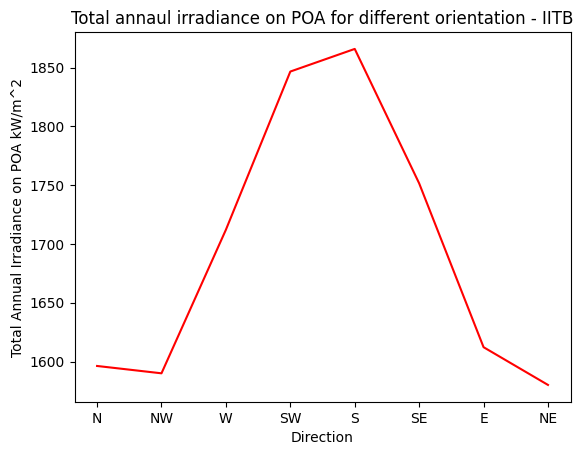

In [38]:
import matplotlib.pyplot as plt
plt.plot(x,y, color= 'red')
plt.xlabel('Direction')
plt.ylabel('Total Annual Irradiance on POA kW/m^2')
plt.title('Total annaul irradiance on POA for different orientation - IITB')
plt.xticks(x, ['N', 'NW', 'W', 'SW', 'S', 'SE', 'E', 'NE'])
#save_fig('POA different')
plt.show()

In [39]:
def bifacial(df,Latitude,file_name, Cordinates, gamma_value):
    pi = math.radians(Latitude)
    beta = pi
    gamma = gamma_value
    Cos_theta_values = []
    Cos_theta_z = []
    for i, j in zip(df['Delta'], df['Hour_angle']):
        delta = math.radians(i)
        omega = math.radians(j)
        A = (math.cos(delta) * math.cos(omega) * math.sin(pi)) - (math.sin(delta)* math.cos(pi))
        B = math.sin(beta) * math.sin(gamma) * math.cos(delta) * math.sin(omega)
        C = (math.cos(delta) * math.cos(omega) * math.cos(pi)) + (math.sin(delta) * math.sin(pi))
        CTheta = (math.sin(beta) * math.cos(gamma) * A) + B + (math.cos(beta) * C)
        Cos_theta_values.append(CTheta)
        CTheta_Z = C
        Cos_theta_z.append(CTheta_Z)
    df['Cos_theta'] = Cos_theta_values
    df['Cos_theta_z'] = Cos_theta_values
    k = df['DNI'].to_numpy()              #Converting the dni values into numpy for array multiplication
    Costheta = df['Cos_theta'].to_numpy()
    i = df['Cos_theta'].to_numpy()   #Cos_theta
    j = df['Cos_theta_z'].to_numpy()  #Cos_theta_z
    l= df['DHI'].to_numpy()           #Id
    g = df['GHI'].to_numpy()
    cos_beta = math.cos(math.radians(beta))
    rd = (1 + cos_beta) / 2                 #Diffuse_reflectivity
    rr = 0.2 * (1 - cos_beta) / 2  #Radiation_reflectivity
    rear_side = 0.95 * 0.2 * 0.5 * g
    It_liu = (k * i) + (l * rd) + ((k + l) * rr) + rear_side #Intensity_tilted
    It_liu = It_liu.tolist()
    df['EPOA'] = It_liu
    total = np.sum(df['EPOA'])
    filename = file_name.strip('.xlsx')
    print(f'For Bifacial {filename} {Cordinates}:')
    print(f'Standard Beta: {Cordinates[0]}°')
    print(f'Standard Gamma: {gamma}°')
    print(f'Maximum  EPOA: {round(total)} W/m^2')
    print()

In [40]:
for f in files:
    Cordinates = location(f)
    a = timeslot_calculation(f)
    b = calculating_hourangle(a, Cordinates[1])
    Standard(b, Cordinates[0],f, Cordinates,0)
    optimization(b,Cordinates[0], f, Cordinates)
    bifacial(b, Cordinates[0],f, Cordinates,0)

For Bifacial Erode_Tamilnadu [11.56, 77.57]:
Standard Beta: 11.56°
Standard Gamma: 0°
Maximum  EPOA: 2088691 W/m^2

For Bifacial Erode_Tamilnadu [11.56, 77.57]:
Optimal beta: 13.57°
Optimal gamma: -1.45°
Maximum  EPOA: 2089442 W/m^2

For Bifacial Erode_Tamilnadu [11.56, 77.57]:
Standard Beta: 11.56°
Standard Gamma: 0°
Maximum  EPOA: 2284330 W/m^2

For Bifacial IITB [19.13, 72.9]:
Standard Beta: 19.13°
Standard Gamma: 0°
Maximum  EPOA: 1865801 W/m^2

For Bifacial IITB [19.13, 72.9]:
Optimal beta: 24.85°
Optimal gamma: -21.66°
Maximum  EPOA: 1881965 W/m^2

For Bifacial IITB [19.13, 72.9]:
Standard Beta: 19.13°
Standard Gamma: 0°
Maximum  EPOA: 2036513 W/m^2

For Bifacial Muzaffarpur_Bihar [26.12, 85.39]:
Standard Beta: 26.12°
Standard Gamma: 0°
Maximum  EPOA: 1888663 W/m^2

For Bifacial Muzaffarpur_Bihar [26.12, 85.39]:
Optimal beta: 26.50°
Optimal gamma: 1.54°
Maximum  EPOA: 1888760 W/m^2

For Bifacial Muzaffarpur_Bihar [26.12, 85.39]:
Standard Beta: 26.12°
Standard Gamma: 0°
Maximum  E